# Movement Island Study: Exploratory Factor Analysis

**Study:** Psychological Factors Influencing Behavioral Intention to Recommend the Movement Island for Older Adults

**Author:** Aurel Berger

**Date:** February 2026

---

## Overview

This notebook replicates the Exploratory Factor Analysis (EFA) reported in the paper:

- **Figure 2:** Item-level correlation matrix (15 items)
- **Table 3:** Factor number determination methods
- **Figure 3:** Scree plot
- **Table 4:** Total variance explained
- **Table 5:** Communalities
- **Figure 4:** Component loadings (unrotated and rotated)

**Important Note:** Sample size (N=16) is severely below recommended minimums for stable factor analysis (N≥100-150). Results should be interpreted as methodological demonstration only.

## 1. Setup

In [2]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from factor_analyzer import FactorAnalyzer
from factor_analyzer.factor_analyzer import calculate_bartlett_sphericity, calculate_kmo
import warnings
warnings.filterwarnings('ignore')

# Set style
plt.rcParams['figure.dpi'] = 300
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.size'] = 10

print("✓ Libraries loaded successfully")

✓ Libraries loaded successfully


## 2. Load Data

In [3]:
# Load cleaned data with TAM items
df = pd.read_csv('../data/cleaned_data.csv')

# Extract TAM item columns (15 items: PU1-3, PEOU1-3, PE1-3, PS1-3, BI1-3)
item_cols = [col for col in df.columns if col.startswith(('PU', 'PEOU', 'PE', 'PS', 'BI'))]
item_cols = sorted(item_cols)  # Sort for consistent ordering

X = df[item_cols]

print(f"✓ Data loaded: N = {len(X)}")
print(f"✓ Items included: {len(item_cols)}")
print(f"\nItems: {item_cols}")

✓ Data loaded: N = 16
✓ Items included: 15

Items: ['BI1', 'BI2', 'BI3', 'PE1', 'PE2', 'PE3', 'PEOU1', 'PEOU2', 'PEOU3', 'PS1', 'PS2', 'PS3', 'PU1', 'PU2', 'PU3']


## 3. Figure 2: Item-Level Correlation Matrix

In [4]:
# Calculate correlation matrix for all 15 items
item_corr = X.corr()

print("="*70)
print("ITEM-LEVEL CORRELATION MATRIX (15 TAM ITEMS)")
print("="*70)
print("\n" + item_corr.round(2).to_string())
print("\n" + "="*70)

# Save correlation matrix
item_corr.to_csv('../outputs/table_item_correlations.csv')
print("\n✓ Item correlation matrix saved to: outputs/table_item_correlations.csv")

ITEM-LEVEL CORRELATION MATRIX (15 TAM ITEMS)

        BI1   BI2   BI3   PE1   PE2   PE3  PEOU1  PEOU2  PEOU3   PS1   PS2   PS3   PU1   PU2   PU3
BI1    1.00  0.59  0.74  0.51  0.68  0.47  -0.23  -0.06   0.31  0.45  0.30  0.37  0.61  0.39  0.39
BI2    0.59  1.00  0.66  0.77  0.50  0.72   0.15   0.13   0.28  0.31  0.69  0.44  0.76  0.28  0.80
BI3    0.74  0.66  1.00  0.60  0.49  0.39   0.22   0.01   0.42  0.47  0.27  0.46  0.79  0.60  0.49
PE1    0.51  0.77  0.60  1.00  0.73  0.38   0.33   0.19   0.25  0.37  0.42  0.42  0.78  0.44  0.77
PE2    0.68  0.50  0.49  0.73  1.00  0.44   0.10   0.26   0.21  0.43  0.24  0.51  0.69  0.49  0.49
PE3    0.47  0.72  0.39  0.38  0.44  1.00  -0.23  -0.04   0.16  0.37  0.69  0.53  0.54  0.36  0.70
PEOU1 -0.23  0.15  0.22  0.33  0.10 -0.23   1.00   0.55   0.36 -0.03 -0.14  0.05  0.44  0.15  0.07
PEOU2 -0.06  0.13  0.01  0.19  0.26 -0.04   0.55   1.00   0.34 -0.05  0.06  0.23  0.45  0.13  0.13
PEOU3  0.31  0.28  0.42  0.25  0.21  0.16   0.36   0.34   1.00 

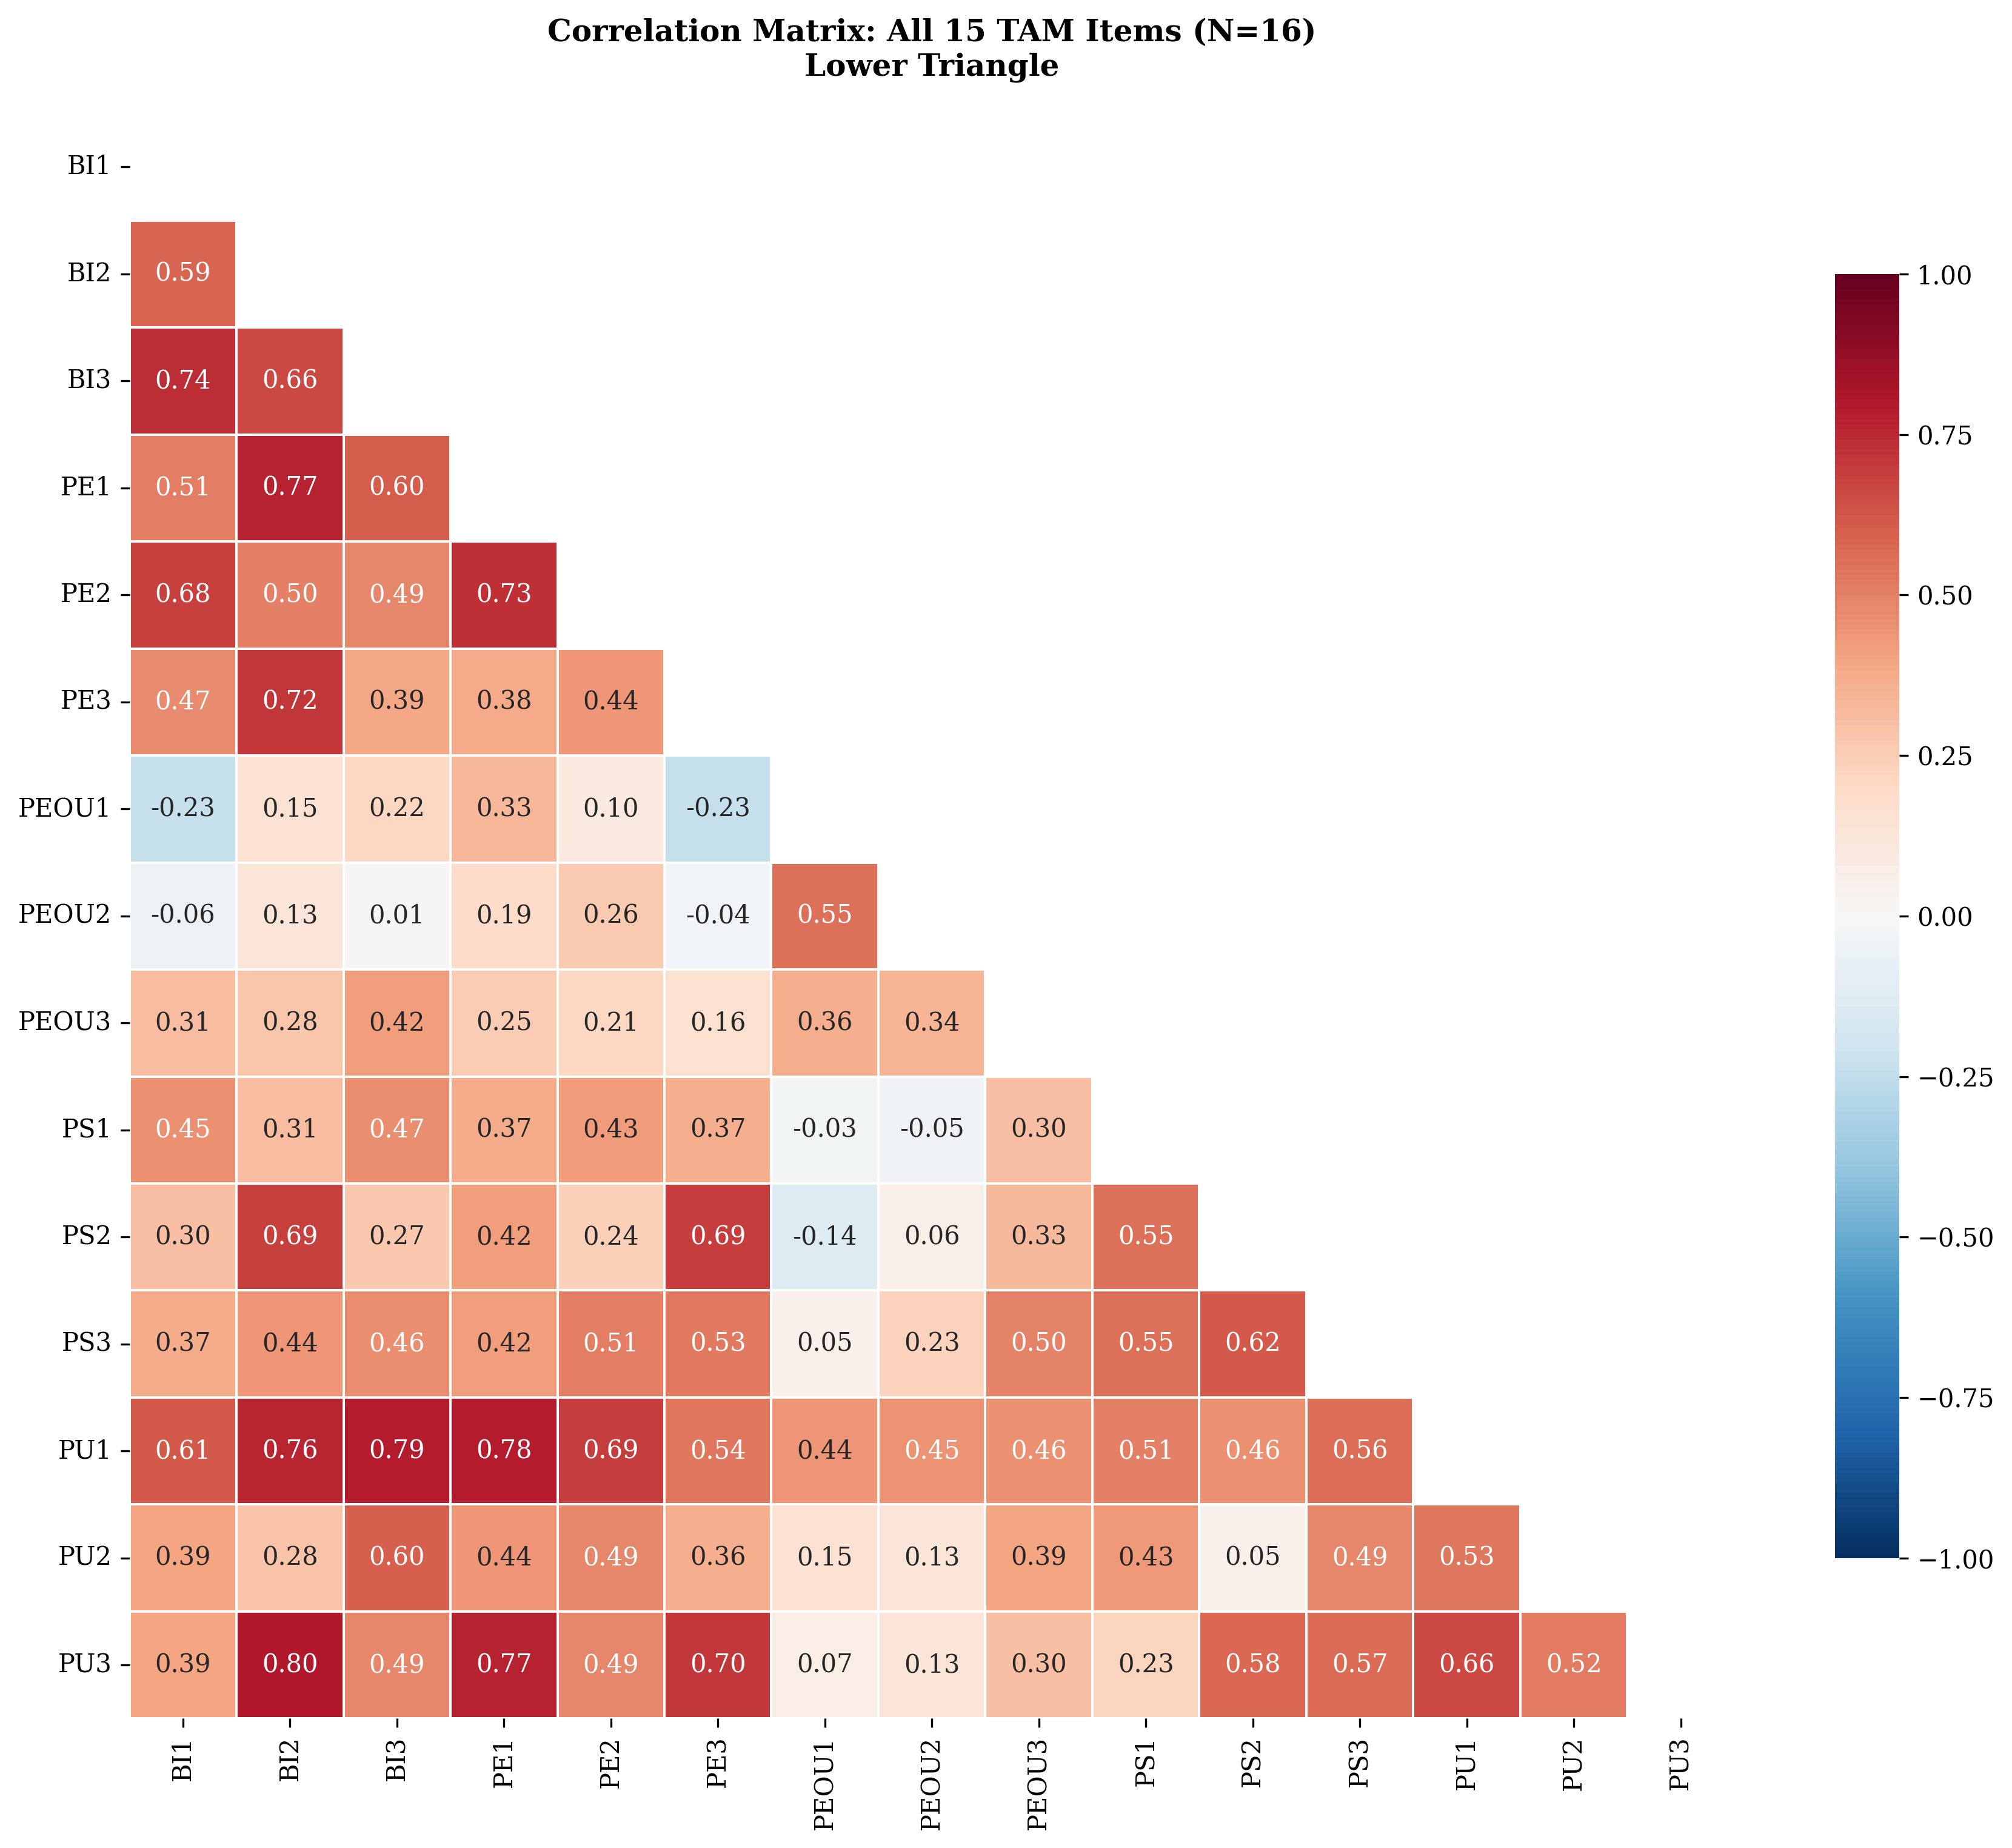

✓ Figure 2 saved to: figures/figure2_item_correlations.png


In [5]:
# Create correlation heatmap (lower triangle only, as in paper)
fig, ax = plt.subplots(figsize=(12, 10))

# Create mask for upper triangle
mask = np.triu(np.ones_like(item_corr, dtype=bool))

# Create heatmap
sns.heatmap(item_corr, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            square=True, linewidths=0.5, cbar_kws={"shrink": 0.8},
            vmin=-1, vmax=1, ax=ax)

# Labels
ax.set_xlabel('', fontweight='bold')
ax.set_ylabel('', fontweight='bold')
ax.set_title('Correlation Matrix: All 15 TAM Items (N=16)\nLower Triangle', 
             fontweight='bold', pad=15, fontsize=12)

plt.tight_layout()
plt.savefig('../figures/figure2_item_correlations.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Figure 2 saved to: figures/figure2_item_correlations.png")

## 4. Adequacy Tests

In [12]:
# Bartlett's test of sphericity
chi_square, p_value = calculate_bartlett_sphericity(X)

# Kaiser-Meyer-Olkin (KMO) test
kmo_all, kmo_model = calculate_kmo(X)

print("="*70)
print("FACTORABILITY TESTS")
print("="*70)
print(f"\nBartlett's Test of Sphericity:")
print(f"  χ² = {chi_square:.2f}")
print(f"  p = {p_value:.4f}")
print(f"  Interpretation: {'✓ Adequate' if p_value < 0.05 else '✗ Not adequate'} (p < .05 indicates correlations exist)")

print(f"\nKaiser-Meyer-Olkin (KMO) Measure:")
print(f"  Overall KMO = {kmo_model:.3f}")
print(f"  Interpretation: ", end="")
if kmo_model >= 0.90:
    print("Marvelous")
elif kmo_model >= 0.80:
    print("Meritorious")
elif kmo_model >= 0.70:
    print("Middling")
elif kmo_model >= 0.60:
    print("Mediocre")
elif kmo_model >= 0.50:
    print("Miserable")
else:
    print("Unacceptable")

print(f"\n⚠️  WARNING: N=16 is severely inadequate for stable factor analysis.")
print(f"    Recommended: N ≥ 100-150 for 15 items.")
print("="*70)

FACTORABILITY TESTS

Bartlett's Test of Sphericity:
  χ² = 214.39
  p = 0.0000
  Interpretation: ✓ Adequate (p < .05 indicates correlations exist)

Kaiser-Meyer-Olkin (KMO) Measure:
  Overall KMO = 0.414
  Interpretation: Unacceptable

⚠️  WARNING: N=16 is severely inadequate for stable factor analysis.
    Recommended: N ≥ 100-150 for 15 items.


## 5. Table 3 & Figure 3: Factor Number Determination

In [21]:
# Fit factor analyzer to extract eigenvalues
# Note: Using scikit-learn's PCA as alternative due to factor_analyzer version issues
from sklearn.decomposition import PCA

# Perform PCA to get eigenvalues
pca = PCA(n_components=len(item_cols))
pca.fit(X)
eigenvalues = pca.explained_variance_

# Kaiser criterion (eigenvalue > 1)
n_factors_kaiser = sum(eigenvalues > 1)

# Theoretical (TAM model)
n_factors_theory = 5

print("="*70)
print("TABLE 3: FACTOR NUMBER DETERMINATION METHODS")
print("="*70)
print(f"\n{'Method':<30} {'Suggested Factors':>20}")
print("-"*70)
print(f"{'Kaiser Criterion (λ > 1)':<30} {n_factors_kaiser:>20}")
print(f"{'Scree Plot (Elbow)':<30} {'1-4 (ambiguous)':>20}")
print(f"{'Theoretical (TAM)':<30} {n_factors_theory:>20}")
print("-"*70)
print(f"\n✓ Five factors extracted based on theoretical TAM model.")
print("="*70)

# Save factor determination table
factor_determination = pd.DataFrame({
    'Method': ['Kaiser (λ > 1)', 'Scree Plot', 'Theoretical (TAM)'],
    'Suggested_Factors': [n_factors_kaiser, '1-4', n_factors_theory]
})
factor_determination.to_csv('../outputs/table3_factor_determination.csv', index=False)
print("\n✓ Table 3 saved to: outputs/table3_factor_determination.csv")

TABLE 3: FACTOR NUMBER DETERMINATION METHODS

Method                            Suggested Factors
----------------------------------------------------------------------
Kaiser Criterion (λ > 1)                          3
Scree Plot (Elbow)                  1-4 (ambiguous)
Theoretical (TAM)                                 5
----------------------------------------------------------------------

✓ Five factors extracted based on theoretical TAM model.

✓ Table 3 saved to: outputs/table3_factor_determination.csv


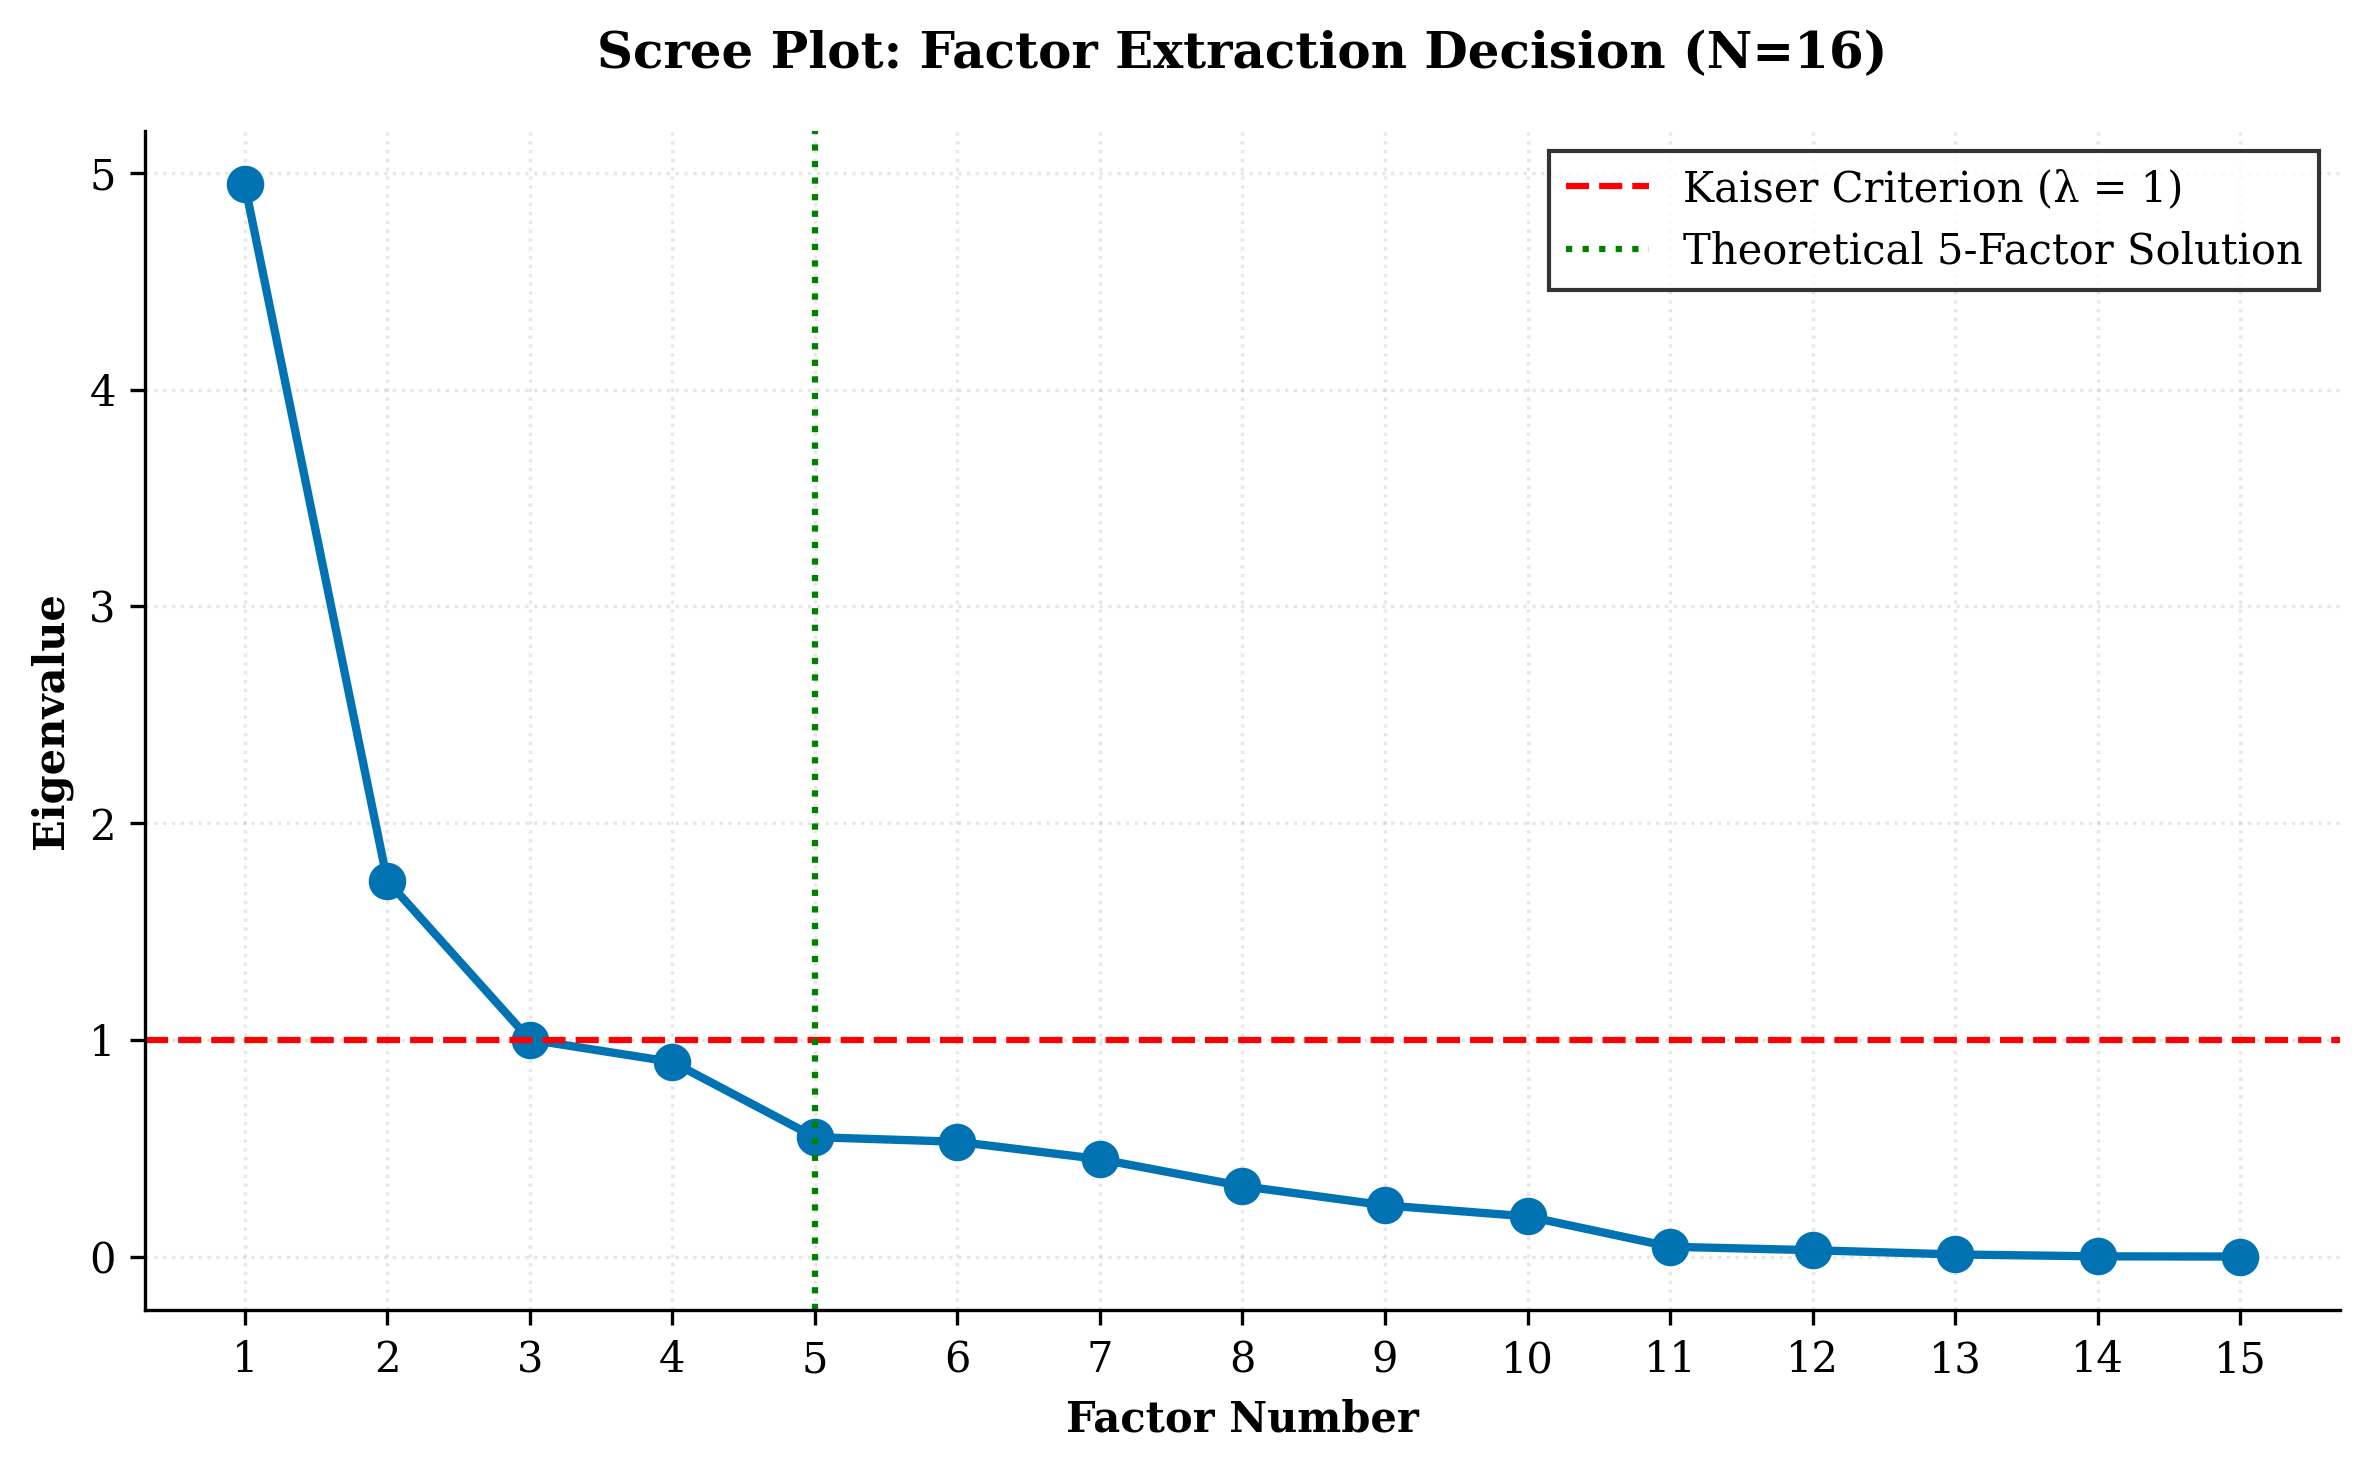

✓ Figure 3 saved to: figures/figure3_scree_plot.png

Eigenvalues: [4.95 1.73 1.   0.9  0.55]


In [22]:
# Figure 3: Scree Plot
fig, ax = plt.subplots(figsize=(8, 5))

factors = range(1, len(eigenvalues) + 1)
ax.plot(factors, eigenvalues, 'o-', linewidth=2, markersize=8, color='#0173B2')

# Kaiser criterion line
ax.axhline(y=1, color='red', linestyle='--', linewidth=1.5, label='Kaiser Criterion (λ = 1)')

# Theoretical 5-factor line
ax.axvline(x=5, color='green', linestyle=':', linewidth=1.5, label='Theoretical 5-Factor Solution')

# Labels
ax.set_xlabel('Factor Number', fontweight='bold')
ax.set_ylabel('Eigenvalue', fontweight='bold')
ax.set_title('Scree Plot: Factor Extraction Decision (N=16)', fontweight='bold', pad=15)
ax.legend(frameon=True, fancybox=False, edgecolor='black')
ax.grid(True, alpha=0.3, linestyle=':')
ax.set_xticks(factors)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('../figures/figure3_scree_plot.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Figure 3 saved to: figures/figure3_scree_plot.png")
print(f"\nEigenvalues: {eigenvalues[:5].round(2)}")

## 6. Extract 5-Factor Solution

In [23]:
# Extract 5 factors using PCA with Varimax rotation
from sklearn.decomposition import PCA
from scipy.linalg import orthogonal_procrustes

n_factors = 5

# Unrotated solution (PCA)
pca_5 = PCA(n_components=n_factors)
scores_unrotated = pca_5.fit_transform(X)
loadings_unrotated = pd.DataFrame(
    pca_5.components_.T * np.sqrt(pca_5.explained_variance_),
    index=item_cols,
    columns=[f'Factor{i+1}' for i in range(n_factors)]
)

# Varimax rotation
def varimax(loadings, gamma=1.0, max_iter=100, tol=1e-6):
    """Perform Varimax rotation on factor loadings."""
    p, k = loadings.shape
    rotation_matrix = np.eye(k)
    
    for _ in range(max_iter):
        old_rotation = rotation_matrix.copy()
        
        # Rotate loadings
        rotated = loadings @ rotation_matrix
        
        # Calculate rotation update
        u, s, vh = np.linalg.svd(loadings.T @ (rotated**3 - (gamma/p) * rotated @ np.diag((rotated**2).sum(axis=0))))
        rotation_matrix = u @ vh
        
        # Check convergence
        if np.allclose(rotation_matrix, old_rotation, atol=tol):
            break
    
    return loadings @ rotation_matrix, rotation_matrix

# Apply Varimax rotation
loadings_rotated_array, rotation_matrix = varimax(loadings_unrotated.values)
loadings_rotated = pd.DataFrame(
    loadings_rotated_array,
    index=item_cols,
    columns=[f'Factor{i+1}' for i in range(n_factors)]
)

# Get communalities (sum of squared loadings for each item)
communalities = pd.DataFrame({
    'Item': item_cols,
    'Communality': (loadings_rotated**2).sum(axis=1).values
})

print("="*70)
print("5-FACTOR SOLUTION EXTRACTED")
print("="*70)
print(f"\n✓ Extraction: Principal Component Analysis")
print(f"✓ Rotation: Varimax with Kaiser Normalization")
print(f"✓ Number of factors: {n_factors}")
print("="*70)

5-FACTOR SOLUTION EXTRACTED

✓ Extraction: Principal Component Analysis
✓ Rotation: Varimax with Kaiser Normalization
✓ Number of factors: 5


## 7. Table 4: Total Variance Explained

In [24]:
# Calculate variance explained for rotated solution
ss_loadings = (loadings_rotated**2).sum(axis=0).values
total_variance = len(item_cols)
prop_variance = ss_loadings / total_variance
cum_variance = np.cumsum(prop_variance)

variance_table = pd.DataFrame({
    'Component': [f'Factor {i+1}' for i in range(n_factors)],
    'SS_Loadings': ss_loadings,
    'Proportion_Variance': prop_variance,
    'Cumulative_Variance': cum_variance
})

print("="*70)
print("TABLE 4: TOTAL VARIANCE EXPLAINED (5 COMPONENTS)")
print("="*70)
print(f"\n{'Component':<15} {'SS Loadings':>12} {'Prop Var':>12} {'Cum Var':>12}")
print("-"*70)
for _, row in variance_table.iterrows():
    print(f"{row['Component']:<15} {row['SS_Loadings']:>12.3f} {row['Proportion_Variance']:>12.3f} {row['Cumulative_Variance']:>12.3f}")
print("-"*70)
print(f"{'Total':<15} {ss_loadings.sum():>12.3f} {prop_variance.sum():>12.3f} {cum_variance[-1]:>12.3f}")
print("="*70)

# Save variance table
variance_table.to_csv('../outputs/table4_variance_explained.csv', index=False)
print("\n✓ Table 4 saved to: outputs/table4_variance_explained.csv")

TABLE 4: TOTAL VARIANCE EXPLAINED (5 COMPONENTS)

Component        SS Loadings     Prop Var      Cum Var
----------------------------------------------------------------------
Factor 1               2.827        0.188        0.188
Factor 2               1.728        0.115        0.304
Factor 3               2.488        0.166        0.470
Factor 4               1.218        0.081        0.551
Factor 5               0.874        0.058        0.609
----------------------------------------------------------------------
Total                  9.134        0.609        0.609

✓ Table 4 saved to: outputs/table4_variance_explained.csv


## 8. Table 5: Communalities

In [25]:
print("="*70)
print("TABLE 5: COMMUNALITIES (N=16)")
print("="*70)
print(f"\n{'Item':<10} {'Communality':>15}")
print("-"*70)
for _, row in communalities.iterrows():
    print(f"{row['Item']:<10} {row['Communality']:>15.3f}")
print("="*70)

print(f"\nCommunalities range: {communalities['Communality'].min():.3f} to {communalities['Communality'].max():.3f}")
print(f"Items with communality ≥ 0.70: {(communalities['Communality'] >= 0.70).sum()} / {len(communalities)}")
print(f"Items with communality < 0.50: {(communalities['Communality'] < 0.50).sum()} / {len(communalities)}")

# Save communalities
communalities.to_csv('../outputs/table5_communalities.csv', index=False)
print("\n✓ Table 5 saved to: outputs/table5_communalities.csv")

TABLE 5: COMMUNALITIES (N=16)

Item           Communality
----------------------------------------------------------------------
BI1                  0.469
BI2                  0.569
BI3                  0.437
PE1                  0.859
PE2                  0.607
PE3                  0.698
PEOU1                0.953
PEOU2                0.501
PEOU3                0.552
PS1                  0.369
PS2                  0.782
PS3                  0.939
PU1                  0.344
PU2                  0.491
PU3                  0.565

Communalities range: 0.344 to 0.953
Items with communality ≥ 0.70: 4 / 15
Items with communality < 0.50: 5 / 15

✓ Table 5 saved to: outputs/table5_communalities.csv


## 9. Figure 4: Component Loadings (Heatmap)

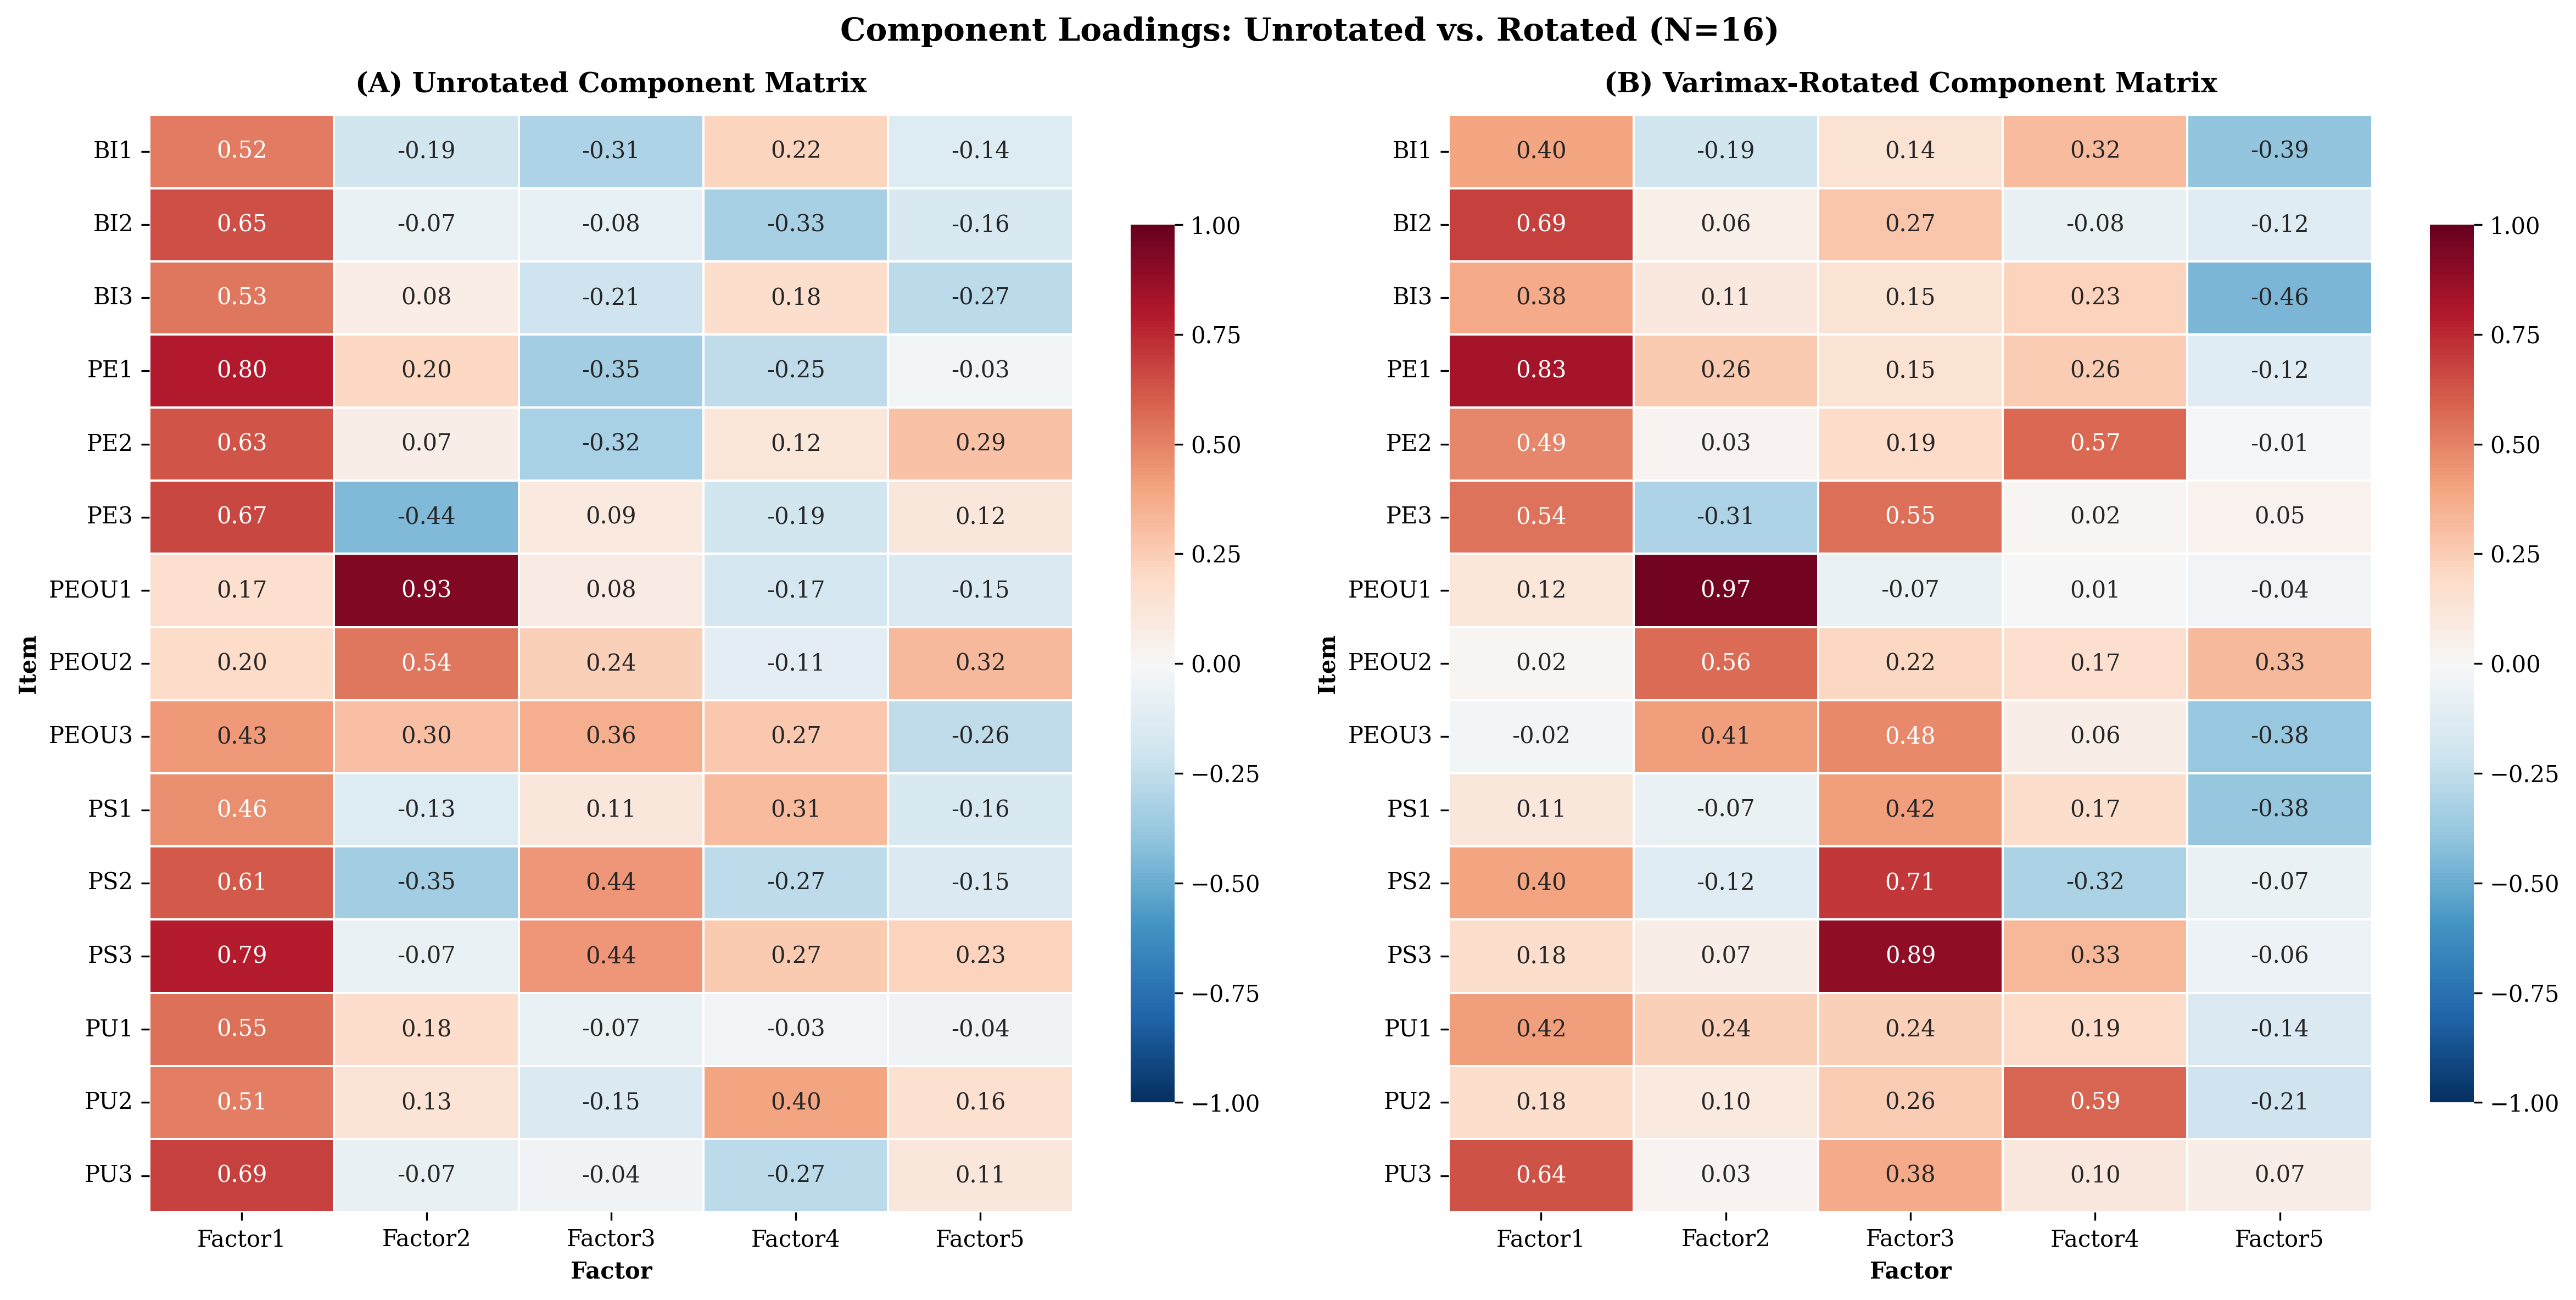

✓ Figure 4 saved to: figures/figure4_loadings_combined.png
✓ Loadings matrices saved to: outputs/efa_loadings_*.csv


In [26]:
# Create side-by-side heatmaps for unrotated and rotated loadings
fig, axes = plt.subplots(1, 2, figsize=(16, 8))

# Unrotated loadings
sns.heatmap(loadings_unrotated, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            square=False, linewidths=0.5, cbar_kws={"shrink": 0.8},
            vmin=-1, vmax=1, ax=axes[0])
axes[0].set_title('(A) Unrotated Component Matrix', fontweight='bold', pad=10)
axes[0].set_xlabel('Factor', fontweight='bold')
axes[0].set_ylabel('Item', fontweight='bold')

# Rotated loadings
sns.heatmap(loadings_rotated, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            square=False, linewidths=0.5, cbar_kws={"shrink": 0.8},
            vmin=-1, vmax=1, ax=axes[1])
axes[1].set_title('(B) Varimax-Rotated Component Matrix', fontweight='bold', pad=10)
axes[1].set_xlabel('Factor', fontweight='bold')
axes[1].set_ylabel('Item', fontweight='bold')

fig.suptitle('Component Loadings: Unrotated vs. Rotated (N=16)', 
             fontweight='bold', fontsize=14, y=0.98)

plt.tight_layout()
plt.savefig('../figures/figure4_loadings_combined.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Figure 4 saved to: figures/figure4_loadings_combined.png")

# Save loadings
loadings_unrotated.to_csv('../outputs/efa_loadings_unrotated.csv')
loadings_rotated.to_csv('../outputs/efa_loadings_rotated.csv')
print("✓ Loadings matrices saved to: outputs/efa_loadings_*.csv")

## 10. Interpretation: Factor Structure

In [27]:
# Identify salient loadings (|λ| ≥ 0.40)
threshold = 0.40
salient_loadings = loadings_rotated.abs() >= threshold

print("="*70)
print("FACTOR STRUCTURE INTERPRETATION")
print("="*70)
print(f"\nSalient loadings threshold: |λ| ≥ {threshold}")
print("\nItems loading on each factor:")
print("-"*70)

for factor in loadings_rotated.columns:
    print(f"\n{factor}:")
    factor_items = loadings_rotated[salient_loadings[factor]].sort_values(by=factor, ascending=False)[factor]
    if len(factor_items) > 0:
        for item, loading in factor_items.items():
            print(f"  {item}: λ = {loading:.3f}")
    else:
        print("  (No salient loadings)")

print("\n" + "="*70)
print("ALIGNMENT WITH THEORETICAL TAM MODEL")
print("="*70)
print("\nExpected structure (5 constructs, 3 items each):")
print("  - PU: PU1, PU2, PU3")
print("  - PEOU: PEOU1, PEOU2, PEOU3")
print("  - PE: PE1, PE2, PE3")
print("  - PS: PS1, PS2, PS3")
print("  - BI: BI1, BI2, BI3")

print("\n⚠️  With N=16, factor structure is highly unstable and does not reliably")
print("    recover theoretical constructs. Results shown for methodological")
print("    demonstration only. Validation with N≥150 required.")
print("="*70)

FACTOR STRUCTURE INTERPRETATION

Salient loadings threshold: |λ| ≥ 0.4

Items loading on each factor:
----------------------------------------------------------------------

Factor1:
  PE1: λ = 0.831
  BI2: λ = 0.686
  PU3: λ = 0.638
  PE3: λ = 0.544
  PE2: λ = 0.488
  PU1: λ = 0.416
  PS2: λ = 0.401

Factor2:
  PEOU1: λ = 0.965
  PEOU2: λ = 0.564
  PEOU3: λ = 0.415

Factor3:
  PS3: λ = 0.889
  PS2: λ = 0.707
  PE3: λ = 0.551
  PEOU3: λ = 0.479
  PS1: λ = 0.417

Factor4:
  PU2: λ = 0.585
  PE2: λ = 0.575

Factor5:
  BI3: λ = -0.458

ALIGNMENT WITH THEORETICAL TAM MODEL

Expected structure (5 constructs, 3 items each):
  - PU: PU1, PU2, PU3
  - PEOU: PEOU1, PEOU2, PEOU3
  - PE: PE1, PE2, PE3
  - PS: PS1, PS2, PS3
  - BI: BI1, BI2, BI3

⚠️  With N=16, factor structure is highly unstable and does not reliably
    recover theoretical constructs. Results shown for methodological
    demonstration only. Validation with N≥150 required.


## 11. Summary

In [28]:
print("="*70)
print("EXPLORATORY FACTOR ANALYSIS SUMMARY")
print("="*70)

print("\n1. Sample Adequacy:")
print(f"   - Sample size: N = {len(X)}")
print(f"   - Items: {len(item_cols)}")
print(f"   - Subject-to-variable ratio: {len(X)}/{len(item_cols)} = {len(X)/len(item_cols):.2f}:1")
print(f"   - Recommended ratio: ≥ 5:1 (ideally 10:1)")
print(f"   - Status: ⚠️ SEVERELY INADEQUATE")

print("\n2. Factor Number Determination:")
print(f"   - Kaiser criterion: {n_factors_kaiser} factors")
print(f"   - Scree plot: Ambiguous (1-4 factors)")
print(f"   - Theoretical TAM: 5 factors")
print(f"   - Extracted: {n_factors} factors (based on theory)")

print("\n3. Variance Explained:")
print(f"   - Total variance (5 factors): {cum_variance[-1]*100:.1f}%")
print(f"   - Factor 1: {prop_variance[0]*100:.1f}%")
print(f"   - Factor 2: {prop_variance[1]*100:.1f}%")
print(f"   - Factor 3: {prop_variance[2]*100:.1f}%")

print("\n4. Communalities:")
print(f"   - Range: {communalities['Communality'].min():.3f} - {communalities['Communality'].max():.3f}")
print(f"   - Mean: {communalities['Communality'].mean():.3f}")
print(f"   - Items ≥ 0.70: {(communalities['Communality'] >= 0.70).sum()} / {len(communalities)}")

print("\n5. Salient Loadings:")
threshold = 0.40
salient_loadings = loadings_rotated.abs() >= threshold
print(f"   - Total (|λ| ≥ 0.40): {salient_loadings.sum().sum()}")
print(f"   - Expected (clean structure): 15 (3 items × 5 factors)")

print("\n" + "="*70)
print("✓ All EFA analyses completed successfully!")
print("="*70)

print("\n⚠️  CRITICAL LIMITATION: N=16 produces unstable factor structures.")
print("    Results should NOT be interpreted substantively.")
print("    Replication with N≥150 is essential before drawing conclusions.")

EXPLORATORY FACTOR ANALYSIS SUMMARY

1. Sample Adequacy:
   - Sample size: N = 16
   - Items: 15
   - Subject-to-variable ratio: 16/15 = 1.07:1
   - Recommended ratio: ≥ 5:1 (ideally 10:1)
   - Status: ⚠️ SEVERELY INADEQUATE

2. Factor Number Determination:
   - Kaiser criterion: 3 factors
   - Scree plot: Ambiguous (1-4 factors)
   - Theoretical TAM: 5 factors
   - Extracted: 5 factors (based on theory)

3. Variance Explained:
   - Total variance (5 factors): 60.9%
   - Factor 1: 18.8%
   - Factor 2: 11.5%
   - Factor 3: 16.6%

4. Communalities:
   - Range: 0.344 - 0.953
   - Mean: 0.609
   - Items ≥ 0.70: 4 / 15

5. Salient Loadings:
   - Total (|λ| ≥ 0.40): 18
   - Expected (clean structure): 15 (3 items × 5 factors)

✓ All EFA analyses completed successfully!

⚠️  CRITICAL LIMITATION: N=16 produces unstable factor structures.
    Results should NOT be interpreted substantively.
    Replication with N≥150 is essential before drawing conclusions.
